# Continuous rainflow counting

Feed a long series in 100 slices through the stateful `RFC` class. After each
chunk, record a damage band:

- **Lower bound** — `damage()`: live closed-cycle damage (open residue ignored).
- **Upper bound** — `damage_as(REPEATED)`: same value plus residue treated as if
  `finalize(REPEATED)` had been called.

Overlay that band with the one-shot `rfc()` damage history and compare the two
final damage values.

The stateful class does not support a per-sample damage history (`spread_damage`);
that comes from `rfc()`.

In [1]:
# Imports

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rfcnt import RFC, ClassParams, ResidualMethod, SDMethod, rfc

In [2]:
# Load data series

from pathlib import Path

data = pd.read_csv(Path("../tests") / "long_series.csv", header=None)
data = np.asarray(data.to_numpy().squeeze(), dtype=np.float64)

class_count = 50
class_range = float(data.max() - data.min())
class_width = class_range / (class_count - 1)
class_offset = float(data.min() - class_width / 2)
class_params = ClassParams(class_count, class_offset, class_width)

n_slices = 100
edges = np.linspace(0, data.size, n_slices + 1, dtype=int)
print(f"{data.size} samples in {n_slices} slices (last slice {data.size - edges[-2]} samples)")

10001 samples in 100 slices (last slice 101 samples)


In [3]:
# One-shot rainflow with per-sample damage history

res = rfc(
    data,
    **class_params._asdict(),
    hysteresis=class_params.class_width,
    residual_method=ResidualMethod.REPEATED,
    spread_damage=SDMethod.TRANSIENT_23c,
)
dh_cum = np.cumsum(res["dh"])
damage_oneshot = float(res["damage"])
print(f"rfc() damage = {damage_oneshot:.6e},  sum(dh) = {float(dh_cum[-1]):.6e}")

rfc() damage = 9.892110e-06,  sum(dh) = 9.892110e-06


In [4]:
# Continuous feed: lower (damage) and upper (damage_as) bound per slice

rf = RFC(
    class_width=class_params.class_width,
    class_count=class_params.class_count,
    class_offset=class_params.class_offset,
    hysteresis=class_params.class_width,
)

slice_end = np.empty(n_slices, dtype=int)
slice_damage_lo = np.empty(n_slices)
slice_damage_hi = np.empty(n_slices)

for i, (start, stop) in enumerate(zip(edges[:-1], edges[1:])):
    rf.feed(data[start:stop])
    slice_end[i] = stop - 1
    slice_damage_lo[i] = rf.damage
    slice_damage_hi[i] = rf.damage_as(ResidualMethod.REPEATED)

rf.finalize(ResidualMethod.REPEATED)
damage_stream = float(rf.damage)
print(f"RFC.finalize() damage     = {damage_stream:.6e}")
print(f"Last damage() (lower)     = {slice_damage_lo[-1]:.6e}")
print(f"Last damage_as() (upper)  = {slice_damage_hi[-1]:.6e}")

RFC.finalize() damage     = 9.892110e-06
Last damage() (lower)     = 1.333448e-07
Last damage_as() (upper)  = 9.892110e-06


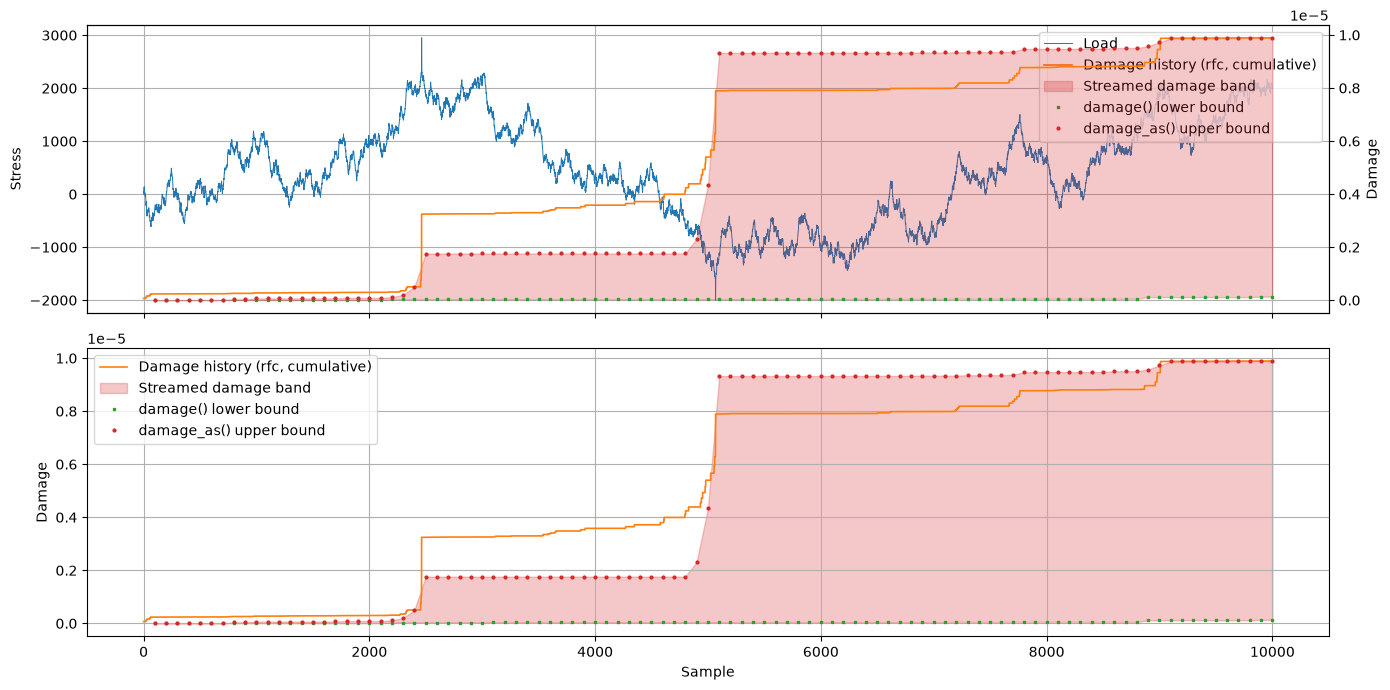

In [7]:
# Overlay load with damage history and the streamed damage band

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(data, lw=0.7, color="C0", label="Load")
ax_d = ax[0].twinx()
ax_d.plot(dh_cum, lw=1.2, color="C1", label="Damage history (rfc, cumulative)")
ax_d.fill_between(
    slice_end,
    slice_damage_lo,
    slice_damage_hi,
    color="C3",
    alpha=0.25,
    label="Streamed damage band",
)
ax_d.plot(slice_end, slice_damage_lo, "s", ms=2, color="C2", label="damage() lower bound")
ax_d.plot(slice_end, slice_damage_hi, "o", ms=2, color="C3", label="damage_as() upper bound")
ax[0].set_ylabel("Stress")
ax_d.set_ylabel("Damage")
ax[0].grid(visible=True, which="both")

h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax_d.get_legend_handles_labels()
ax[0].legend(h0 + h1, l0 + l1, loc="upper right")

ax[1].plot(dh_cum, lw=1.2, color="C1", label="Damage history (rfc, cumulative)")
ax[1].fill_between(
    slice_end,
    slice_damage_lo,
    slice_damage_hi,
    color="C3",
    alpha=0.25,
    label="Streamed damage band",
)
ax[1].plot(slice_end, slice_damage_lo, "s", ms=2, color="C2", label="damage() lower bound")
ax[1].plot(slice_end, slice_damage_hi, "o", ms=2, color="C3", label="damage_as() upper bound")
ax[1].set_ylabel("Damage")
ax[1].set_xlabel("Sample")
ax[1].grid(visible=True, which="both")
ax[1].legend(loc="best")

plt.tight_layout()
plt.show()

In [8]:
# Compare final damage from both procedures

rel = abs(damage_stream - damage_oneshot) / max(damage_oneshot, 1e-30)
print(f"One-shot rfc() damage:          {damage_oneshot:.6e}")
print(f"Stateful RFC.finalize() damage: {damage_stream:.6e}")
print(f"Last damage() lower bound:      {slice_damage_lo[-1]:.6e}")
print(f"Last damage_as() upper bound:   {slice_damage_hi[-1]:.6e}")
print(f"sum(dh):                        {float(dh_cum[-1]):.6e}")
print(f"Relative difference (stream vs rfc): {rel:.3e}")

if np.any(slice_damage_lo > slice_damage_hi + 1e-18):
    msg = "Lower bound damage() exceeds upper bound damage_as()"
    raise AssertionError(msg)
if not np.isclose(damage_stream, damage_oneshot, rtol=1e-10, atol=0.0):
    msg = "Streamed RFC damage does not match one-shot rfc()"
    raise AssertionError(msg)
if not np.isclose(slice_damage_hi[-1], damage_stream, rtol=1e-10, atol=0.0):
    msg = "Last damage_as() does not match RFC.finalize()"
    raise AssertionError(msg)
if not np.isclose(dh_cum[-1], damage_oneshot, rtol=1e-10, atol=0.0):
    msg = "sum(dh) does not match rfc() damage"
    raise AssertionError(msg)

print("OK: streamed, one-shot, last upper bound and sum(dh) agree.")
print("OK: damage() stays at or below damage_as() on every slice.")

One-shot rfc() damage:          9.892110e-06
Stateful RFC.finalize() damage: 9.892110e-06
Last damage() lower bound:      1.333448e-07
Last damage_as() upper bound:   9.892110e-06
sum(dh):                        9.892110e-06
Relative difference (stream vs rfc): 0.000e+00
OK: streamed, one-shot, last upper bound and sum(dh) agree.
OK: damage() stays at or below damage_as() on every slice.
